                                 Earthquake Data Analysis (2000-2026)

In [4]:
# importing the libraries i need for this project
import pandas as pd        # for loading and working with the dataset
import numpy as np         # for some math operations
import matplotlib.pyplot as plt   # for making graphs
import seaborn as sns      # for nicer looking graphs

# setting a basic style so all plots look clean
sns.set_style("whitegrid")


In [5]:
# loading the raw dataset
df = pd.read_csv("earthquakes_1900_2026.csv")

# converting time column to proper datetime format
df['time'] = pd.to_datetime(df['time'], errors='coerce', format='mixed')

# keeping only data from year 2000 to 2026
# older data has less reliable recording so we filter it out
df = df[(df['time'].dt.year >= 2000) & (df['time'].dt.year <= 2026)]

# saving this filtered version so we dont have to do this step every time
df.to_csv("earthquake_2000_2026.csv", index=False)
print("file saved!")
print("total rows:", len(df))


file saved!
total rows: 691176


In [6]:
# now loading the saved file for our actual analysis
df = pd.read_csv("earthquake_2000_2026.csv")

# quick check - how many rows and columns do we have
print("Shape:", df.shape)


Shape: (691176, 23)


In [8]:
# seeing the first 5 rows to understand what the data looks like
df.head()


,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
0,usp0009kjw,2000-01-01 01:19:26.990000+00:00,2000,1,1,1,41.9270,20.543,10.0,4.5,...,0,Moderate (4-5),Shallow (0-70km),NaN,NaN,NaN,1.14,us,2014-11-07T01:09:14.397Z,reviewed
1,usp0009kjx,2000-01-01 02:10:15.590000+00:00,2000,1,1,2,41.9150,20.534,6.2,2.9,...,0,Minor (2.5-3),Shallow (0-70km),NaN,NaN,NaN,NaN,us,2014-11-07T01:09:14.652Z,reviewed
2,usp0009kjz,2000-01-01 02:12:13.450000+00:00,2000,1,1,2,-11.3480,164.568,33.0,4.3,...,0,Moderate (4-5),Shallow (0-70km),NaN,NaN,NaN,1.16,us,2014-11-07T01:09:14.702Z,reviewed
3,usp0009kk0,2000-01-01 03:20:57.300000+00:00,2000,1,1,3,48.1190,-2.959,3.0,2.7,...,0,Minor (2.5-3),Shallow (0-70km),NaN,NaN,NaN,NaN,us,2014-11-07T01:09:14.711Z,reviewed
4,ak0001pgua9,2000-01-01 03:24:23.217000+00:00,2000,1,1,3,62.7531,-150.301,93.3,2.5,...,0,Minor (2.5-3),Intermediate (70-300km),NaN,NaN,NaN,0.78,ak,2020-02-20T20:06:40.502Z,reviewed


In [9]:
# seeing the last 5 rows just to confirm data goes till recent years
df.tail()


,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
691171,us6000smnq,2026-04-04 21:23:59.497000+00:00,2026,4,94,21,24.051800,121.617500,23.376,4.400000,...,0,Moderate (4-5),Shallow (0-70km),57.0,66.0,0.12300,0.95,us,2026-04-05T01:59:05.040Z,reviewed
691172,us6000smp0,2026-04-04 22:04:38.745000+00:00,2026,4,94,22,39.922200,-107.134400,5.000,2.500000,...,0,Minor (2.5-3),Shallow (0-70km),20.0,83.0,0.45400,1.04,us,2026-04-05T00:54:17.040Z,reviewed
691173,us6000smp9,2026-04-04 22:31:20.621000+00:00,2026,4,94,22,-31.520300,-177.976600,30.861,5.000000,...,0,Moderate (4-5),Shallow (0-70km),26.0,151.0,2.26800,1.25,us,2026-04-04T22:50:25.040Z,reviewed
691174,us6000smpb,2026-04-04 22:37:50.166000+00:00,2026,4,94,22,1.447300,126.614600,35.000,4.500000,...,0,Moderate (4-5),Shallow (0-70km),39.0,99.0,7.10900,1.11,us,2026-04-05T01:46:17.040Z,reviewed
691175,ci41432840,2026-04-04 23:37:55.060000+00:00,2026,4,94,23,33.982666,-116.907837,9.400,3.262396,...,0,Light (3-4),Shallow (0-70km),105.0,35.0,0.08598,0.19,ci,2026-04-05T20:56:53.934Z,reviewed


                                        Understanding the Data

In [10]:
# this gives us info about column names, data types and how many non-null values each has
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691176 entries, 0 to 691175
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              691176 non-null  object 
 1   time            691176 non-null  object 
 2   year            691176 non-null  int64  
 3   month           691176 non-null  int64  
 4   day_of_year     691176 non-null  int64  
 5   hour            691176 non-null  int64  
 6   latitude        691176 non-null  float64
 7   longitude       691176 non-null  float64
 8   depth           691176 non-null  float64
 9   mag             691176 non-null  float64
 10  magType         691175 non-null  object 
 11  place           691176 non-null  object 
 12  type            691176 non-null  object 
 13  tsunami         691176 non-null  int64  
 14  mag_category    691176 non-null  object 
 15  depth_category  691170 non-null  object 
 16  nst             458153 non-null  float64
 17  gap       

In [11]:
# column names in our dataset
df.columns


Index(['id', 'time', 'year', 'month', 'day_of_year', 'hour', 'latitude',
       'longitude', 'depth', 'mag', 'magType', 'place', 'type', 'tsunami',
       'mag_category', 'depth_category', 'nst', 'gap', 'dmin', 'rms', 'net',
       'updated', 'status'],
      dtype='object')

In [12]:
# statistical summary - mean, min, max etc for all number columns
df.describe()


,year,month,day_of_year,hour,latitude,longitude,depth,mag,tsunami,nst,gap,dmin,rms
count,691176.000000,691176.000000,691176.000000,691176.000000,691176.000000,691176.000000,691176.000000,691176.000000,691176.0,458153.000000,573394.000000,327063.000000,584118.000000
mean,2013.029757,6.455393,180.911001,11.548277,19.127278,-21.270139,56.089288,3.803286,0.0,37.601231,137.379618,2.428587,0.697262
std,7.510104,3.420907,104.478619,6.987889,30.591058,122.893261,102.616669,0.866226,0.0,54.932509,76.068815,4.156343,0.415580
min,2000.000000,1.000000,1.000000,0.000000,-84.493200,-179.999700,-3.740000,0.700000,0.0,0.000000,6.500000,0.000000,-1.000000
25%,2006.000000,4.000000,91.000000,5.000000,-5.139000,-128.366000,10.000000,2.940000,0.0,11.000000,76.700000,0.336000,0.440000
50%,2013.000000,7.000000,182.000000,12.000000,20.434700,-66.836833,20.000000,4.000000,0.0,21.000000,123.000000,1.116000,0.710000
75%,2020.000000,9.000000,271.000000,18.000000,42.943000,121.071625,51.400000,4.500000,0.0,41.000000,190.000000,2.833000,0.940000
max,2026.000000,12.000000,365.000000,23.000000,87.386000,180.000000,735.800000,9.100000,0.0,934.000000,359.000000,127.420000,104.330000


In [13]:
# checking how many missing values are there in each column
df.isnull().sum()

id                     0
time                   0
year                   0
month                  0
day_of_year            0
hour                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                1
place                  0
type                   0
tsunami                0
mag_category           0
depth_category         6
nst               233023
gap               117782
dmin              364113
rms               107058
net                    0
updated                0
status                 0
dtype: int64

Before we analyze anything, we need to clean the data.
This means handling missing values, fixing column types, and removing useless stuff.

In [14]:
# first converting time to proper datetime (in case it wasnt loaded correctly)
df['time'] = pd.to_datetime(df['time'], errors='coerce', format='mixed')

# dropping rows where time is missing because we cant use them in time analysis
df = df.dropna(subset=['time'])
print(df)
print("rows after dropping bad time values:", len(df))


                 id                             time  year  month  \
0        usp0009kjw 2000-01-01 01:19:26.990000+00:00  2000      1   
1        usp0009kjx 2000-01-01 02:10:15.590000+00:00  2000      1   
2        usp0009kjz 2000-01-01 02:12:13.450000+00:00  2000      1   
3        usp0009kk0 2000-01-01 03:20:57.300000+00:00  2000      1   
4       ak0001pgua9 2000-01-01 03:24:23.217000+00:00  2000      1   
...             ...                              ...   ...    ...   
691171   us6000smnq 2026-04-04 21:23:59.497000+00:00  2026      4   
691172   us6000smp0 2026-04-04 22:04:38.745000+00:00  2026      4   
691173   us6000smp9 2026-04-04 22:31:20.621000+00:00  2026      4   
691174   us6000smpb 2026-04-04 22:37:50.166000+00:00  2026      4   
691175   ci41432840 2026-04-04 23:37:55.060000+00:00  2026      4   

        day_of_year  hour   latitude   longitude   depth       mag  ...  \
0                 1     1  41.927000   20.543000  10.000  4.500000  ...   
1                 1  

In [15]:
# filling missing values in magnitude and depth with median
# we use median because these columns have some extreme values (outliers)
# median is less affected by outliers than mean
df['mag']   = df['mag'].fillna(df['mag'].median())
df['depth'] = df['depth'].fillna(df['depth'].median())

# for latitude and longitude we use mean
# because geographic coordinates are usually symmetric (no big outliers)
df['latitude']  = df['latitude'].fillna(df['latitude'].mean())
df['longitude'] = df['longitude'].fillna(df['longitude'].mean())

print("missing values after filling mag, depth, lat, lon:")
print(df[['mag','depth','latitude','longitude']].isnull().sum())


missing values after filling mag, depth, lat, lon:
mag          0
depth        0
latitude     0
longitude    0
dtype: int64


In [16]:
# filling missing values in some other columns too
df['nst'] = df['nst'].fillna(df['nst'].median())  # number of stations
df['gap'] = df['gap'].fillna(df['gap'].median())   # gap between stations
df['dmin'] = df['dmin'].fillna(df['dmin'].median()) # distance to nearest station
df['rms']  = df['rms'].fillna(df['rms'].median())  # root mean square error
print("Update dataset")
print(df)
print("remaining nulls in these columns:")
print(df[['nst','gap','dmin','rms']].isnull().sum())


Update dataset
                 id                             time  year  month  \
0        usp0009kjw 2000-01-01 01:19:26.990000+00:00  2000      1   
1        usp0009kjx 2000-01-01 02:10:15.590000+00:00  2000      1   
2        usp0009kjz 2000-01-01 02:12:13.450000+00:00  2000      1   
3        usp0009kk0 2000-01-01 03:20:57.300000+00:00  2000      1   
4       ak0001pgua9 2000-01-01 03:24:23.217000+00:00  2000      1   
...             ...                              ...   ...    ...   
691171   us6000smnq 2026-04-04 21:23:59.497000+00:00  2026      4   
691172   us6000smp0 2026-04-04 22:04:38.745000+00:00  2026      4   
691173   us6000smp9 2026-04-04 22:31:20.621000+00:00  2026      4   
691174   us6000smpb 2026-04-04 22:37:50.166000+00:00  2026      4   
691175   ci41432840 2026-04-04 23:37:55.060000+00:00  2026      4   

        day_of_year  hour   latitude   longitude   depth       mag  ...  \
0                 1     1  41.927000   20.543000  10.000  4.500000  ...   
1     

In [17]:
# checking if there are any duplicate rows
print("duplicate rows:", df.duplicated().sum())

# removing them if any
df = df.drop_duplicates()

duplicate rows: 0


In [18]:
# checking what unique values tsunami column has
print(df['tsunami'].unique())

# it only has one value so it gives us no useful information
# dropping it
df = df.drop(columns=['tsunami'])
print(df)
print("tsunami column removed")


[0]
                 id                             time  year  month  \
0        usp0009kjw 2000-01-01 01:19:26.990000+00:00  2000      1   
1        usp0009kjx 2000-01-01 02:10:15.590000+00:00  2000      1   
2        usp0009kjz 2000-01-01 02:12:13.450000+00:00  2000      1   
3        usp0009kk0 2000-01-01 03:20:57.300000+00:00  2000      1   
4       ak0001pgua9 2000-01-01 03:24:23.217000+00:00  2000      1   
...             ...                              ...   ...    ...   
691171   us6000smnq 2026-04-04 21:23:59.497000+00:00  2026      4   
691172   us6000smp0 2026-04-04 22:04:38.745000+00:00  2026      4   
691173   us6000smp9 2026-04-04 22:31:20.621000+00:00  2026      4   
691174   us6000smpb 2026-04-04 22:37:50.166000+00:00  2026      4   
691175   ci41432840 2026-04-04 23:37:55.060000+00:00  2026      4   

        day_of_year  hour   latitude   longitude   depth       mag  ...  \
0                 1     1  41.927000   20.543000  10.000  4.500000  ...   
1                

In [19]:
# final check - how many nulls are left
print("total missing values left:", df.isnull().sum().sum())
print("final shape:", df.shape)


total missing values left: 7
final shape: (691176, 22)


Here we create some new columns from the existing data.
This helps us do better analysis (like trends by year or month).

In [20]:
# extracting year, month, day and hour from the time column
# this will help us study earthquake patterns over time
df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day']   = df['time'].dt.day
df['hour']  = df['time'].dt.hour

df[['time', 'year', 'month', 'day', 'hour']].head()


,time,year,month,day,hour
0,2000-01-01 01:19:26.990000+00:00,2000,1,1,1
1,2000-01-01 02:10:15.590000+00:00,2000,1,1,2
2,2000-01-01 02:12:13.450000+00:00,2000,1,1,2
3,2000-01-01 03:20:57.300000+00:00,2000,1,1,3
4,2000-01-01 03:24:23.217000+00:00,2000,1,1,3


In [21]:
# creating magnitude categories to group earthquakes by severity
# based on the Richter scale:
# below 4.0  -> Low (minor, usually not felt much)
# 4.0 to 6.0 -> Moderate (felt, some minor damage)
# 6.0 to 7.0 -> Strong (significant damage possible)
# above 7.0  -> Major (severe, can be destructive)

df['mag_cat'] = pd.cut(df['mag'],
                       bins=[0, 4, 6, 7, 12],
                       labels=['Low', 'Moderate', 'Strong', 'Major'])

# checking how many earthquakes fall in each category
df['mag_cat'].value_counts()


mag_cat
Low         354104
Moderate    334040
Strong        2717
Major          315
Name: count, dtype: int64

Separating Numerical and Categorical Columns
We separate columns by type so we can apply the right kind of analysis to each.

In [22]:
num_cols = []
cat_cols = []

for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        cat_cols.append(col)
    else:
        num_cols.append(col)

print("Numerical columns:", num_cols)
print()
print("Categorical columns:", cat_cols)


Numerical columns: ['time', 'year', 'month', 'day_of_year', 'hour', 'latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms', 'day']

Categorical columns: ['id', 'magType', 'place', 'type', 'mag_category', 'depth_category', 'net', 'updated', 'status', 'mag_cat']


Distribution of Magnitude
This histogram shows how earthquake magnitudes are spread across the dataset.
We use kde=True to draw a smooth curve over the bars.

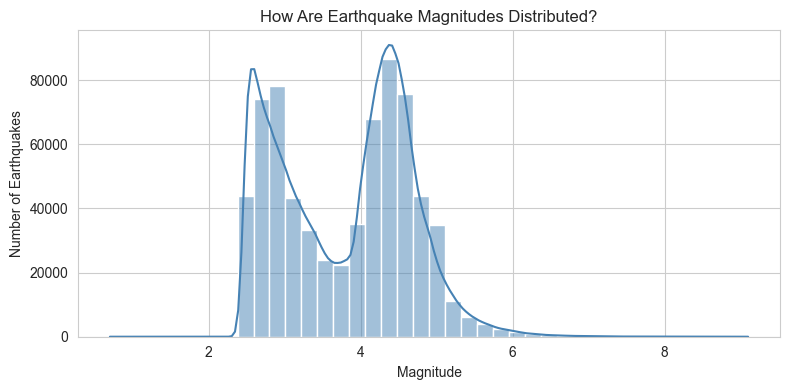

In [38]:
plt.figure(figsize=(8, 4))
sns.histplot(df['mag'], bins=40, kde=True, color='steelblue')

plt.title("How Are Earthquake Magnitudes Distributed?")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.tight_layout()
plt.show()

# most earthquakes are low magnitude (around 2-4)
# very few go above 7 - those are rare but dangerous


Distribution of Depth
Depth tells us how far underground the earthquake started.
Shallow earthquakes (less than 70km) tend to cause more damage on the surface.


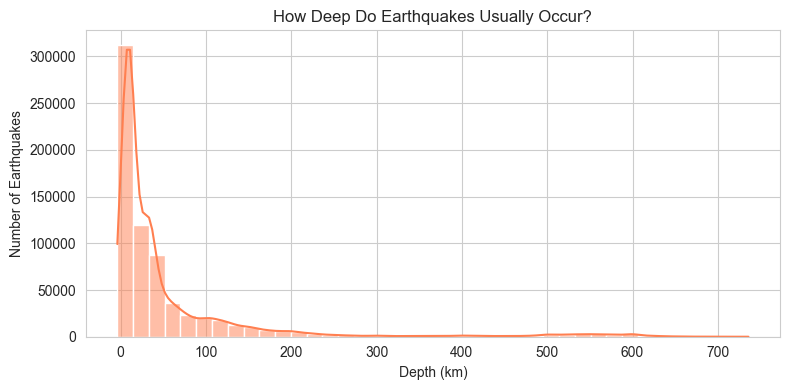

In [39]:
plt.figure(figsize=(8, 4))
sns.histplot(df['depth'], bins=40, kde=True, color='coral')

plt.title("How Deep Do Earthquakes Usually Occur?")
plt.xlabel("Depth (km)")
plt.ylabel("Number of Earthquakes")
plt.tight_layout()
plt.show()

# most earthquakes are shallow (under 100 km)
# deeper ones are much less common


Boxplots - Checking for Outliers
Boxplots show the middle 50% of values (the box), the median (line inside),
and any extreme values (dots) which are outliers.


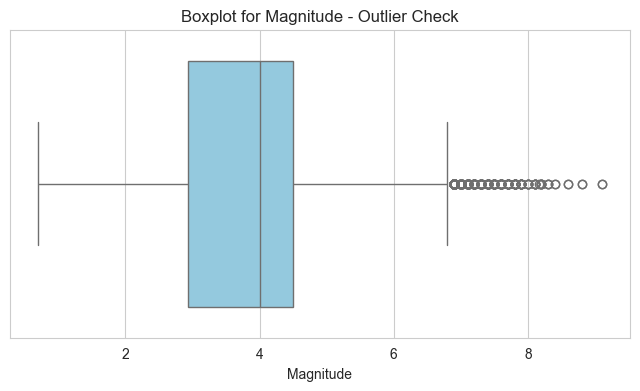

In [25]:
plt.figure(figsize=(8, 4)) # Create a fresh figure
sns.boxplot(x=df['mag'], color='skyblue')
plt.title("Boxplot for Magnitude - Outlier Check")
plt.xlabel("Magnitude")
plt.show()
plt.show()

# magnitude doesnt have too many extreme outliers


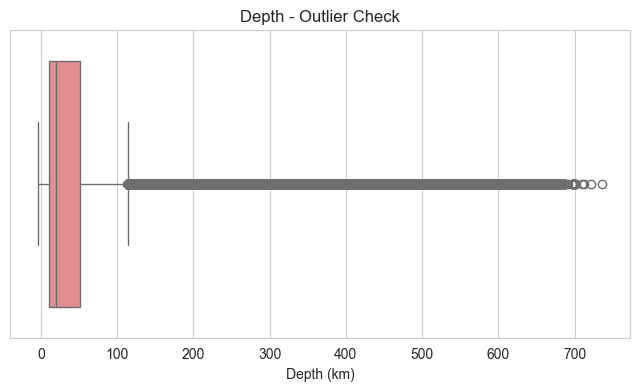

In [37]:
plt.figure(figsize=(8, 4)) # Create a brand new figure
sns.boxplot(x=df['depth'], color='lightcoral')
plt.title("Depth - Outlier Check")
plt.xlabel("Depth (km)")
plt.show()
# depth has some very deep earthquakes (600+ km) which are rare

Depth vs Magnitude (Scatter Plot)
We want to check - do deeper earthquakes tend to be stronger?
The scatter plot helps us see if there's any pattern between these two variables.

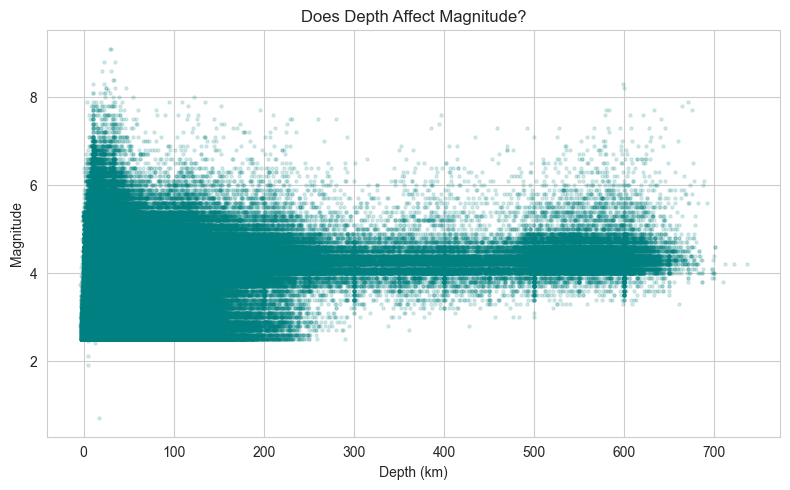

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df['depth'], df['mag'], alpha=0.15, s=5, color='teal')

plt.title("Does Depth Affect Magnitude?")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()

# no clear pattern - depth and magnitude dont seem strongly related


Depth vs Magnitude - Colored by Category
Same scatter plot but now each dot is colored by the earthquake category.
This makes it easier to see where major vs low earthquakes fall.

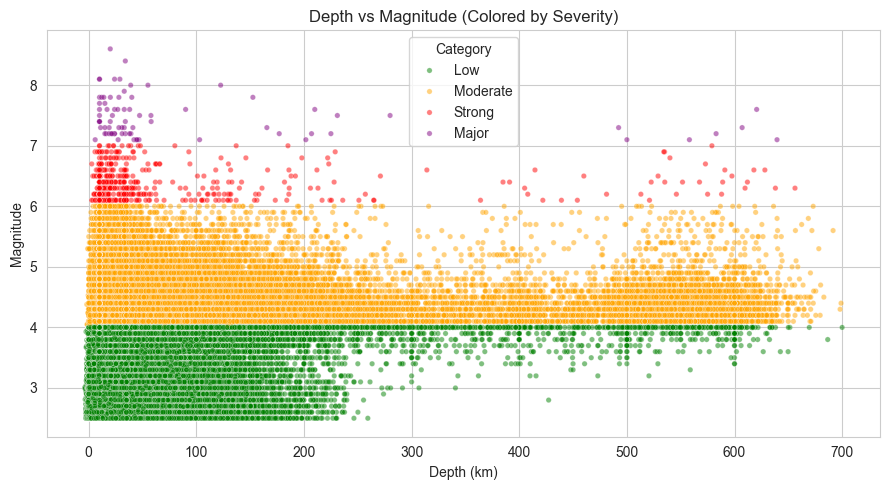

In [28]:
# using a sample of 20% data to keep the plot fast and clean
sample = df.sample(frac=0.2, random_state=42)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=sample, x='depth', y='mag',hue='mag_cat',
                palette={'Low':'green','Moderate':'orange',
                         'Strong':'red','Major':'purple'},alpha=0.5, s=15)

plt.title("Depth vs Magnitude (Colored by Severity)")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


How Many Earthquakes in Each Category?
This bar chart shows which magnitude category has the most earthquakes.

C:\Users\vanis\AppData\Local\Temp\ipykernel_13652\3086024275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mag_cat',


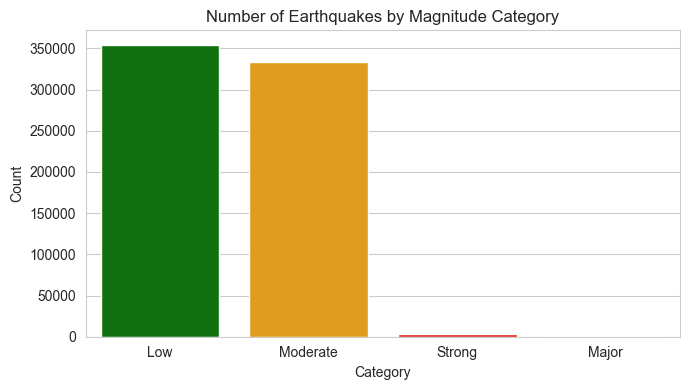

In [29]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='mag_cat',
              order=['Low','Moderate','Strong','Major'],
              palette=['green','orange','red','purple'])

plt.title("Number of Earthquakes by Magnitude Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# low magnitude earthquakes are by far the most common
# major ones are very rare which is a good thing


Pie Chart - Proportion of Each Category
This shows the same information as the bar chart but as percentages.

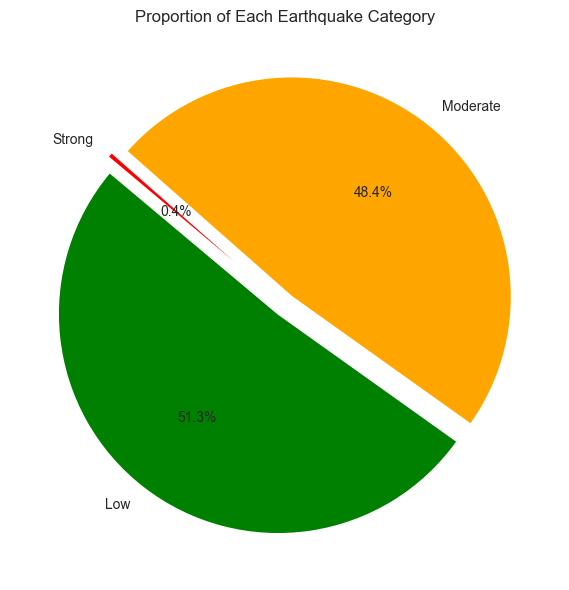

In [30]:
cat_counts = df['mag_cat'].value_counts().reindex(['Low','Moderate','Strong'])

plt.figure(figsize=(6, 6))
plt.pie(cat_counts,
        labels=cat_counts.index,
        autopct='%1.1f%%',
        colors=['green','orange','red'],
        startangle=140,
        explode=(0.05, 0.05,0.05))

plt.title("Proportion of Each Earthquake Category")
plt.tight_layout()
plt.show()


Earthquakes Per Year (Time Series)
Has the number of recorded earthquakes changed over the years?
This line graph shows the trend from 2000 to 2026.

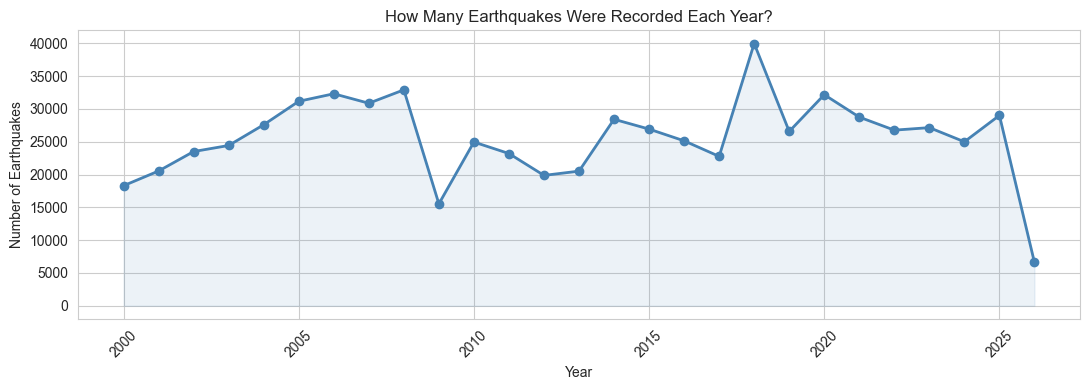

In [31]:
year_counts = df.groupby('year').size()

plt.figure(figsize=(11, 4))
plt.plot(year_counts.index, year_counts.values,
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(year_counts.index, year_counts.values, alpha=0.1, color='steelblue')

plt.title("How Many Earthquakes Were Recorded Each Year?")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# some years show sudden spikes - these often correspond to big earthquake events
# followed by many aftershocks


Average Magnitude Per Year
Did the average strength of earthquakes change over time?

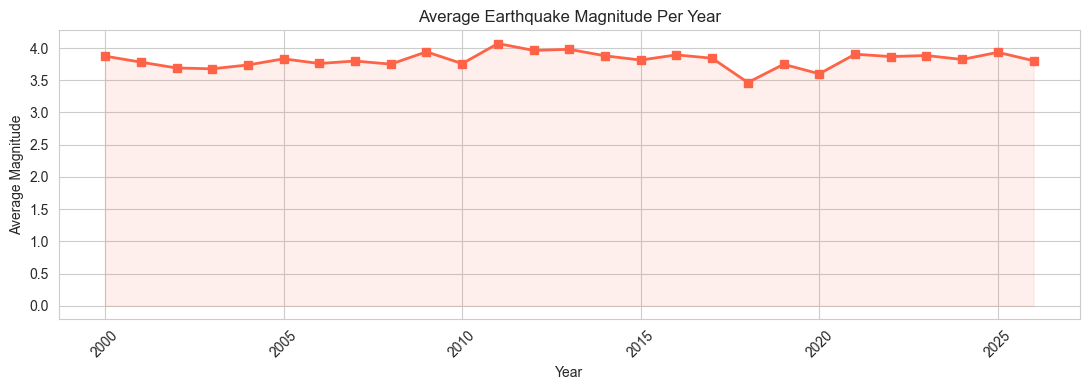

In [32]:
avg_mag = df.groupby('year')['mag'].mean()

plt.figure(figsize=(11, 4))
plt.plot(avg_mag.index, avg_mag.values,
         marker='s', color='tomato', linewidth=2)
plt.fill_between(avg_mag.index, avg_mag.values, alpha=0.1, color='tomato')

plt.title("Average Earthquake Magnitude Per Year")
plt.xlabel("Year")
plt.ylabel("Average Magnitude")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly Pattern
Are earthquakes more common in certain months? This helps us check for any seasonal pattern.

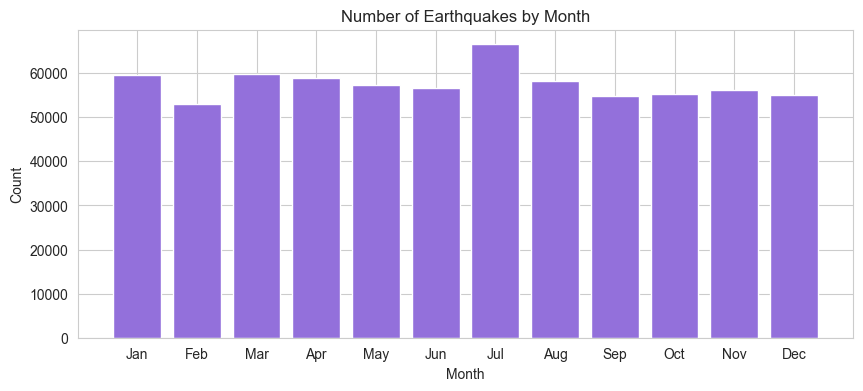

In [33]:
month_counts = df.groupby('month').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.bar(month_labels, month_counts.values, color='mediumpurple', edgecolor='white')

plt.title("Number of Earthquakes by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# earthquakes are spread fairly evenly across all months
# no clear seasonal pattern - they can happen any time of the year


Correlation Heatmap
A heatmap shows how strongly two columns are related to each other.
Numbers close to 1 or -1 mean there is some relationship, and close to 0 means not much.

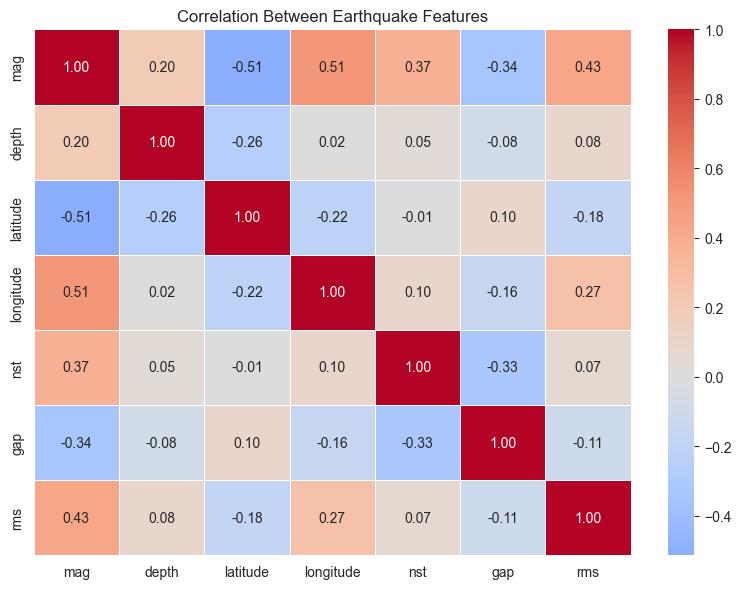

In [34]:
cols_for_corr = ['mag', 'depth', 'latitude', 'longitude', 'nst', 'gap', 'rms']
corr = df[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)

plt.title("Correlation Between Earthquake Features")
plt.tight_layout()
plt.show()

# most features dont have a strong linear relationship with each other
# nst and gap have some negative correlation (more stations = smaller gap)


Where Do Earthquakes Happen?
Plotting latitude vs longitude gives us a rough idea of where earthquakes occur around the world.
Each dot is one earthquake.

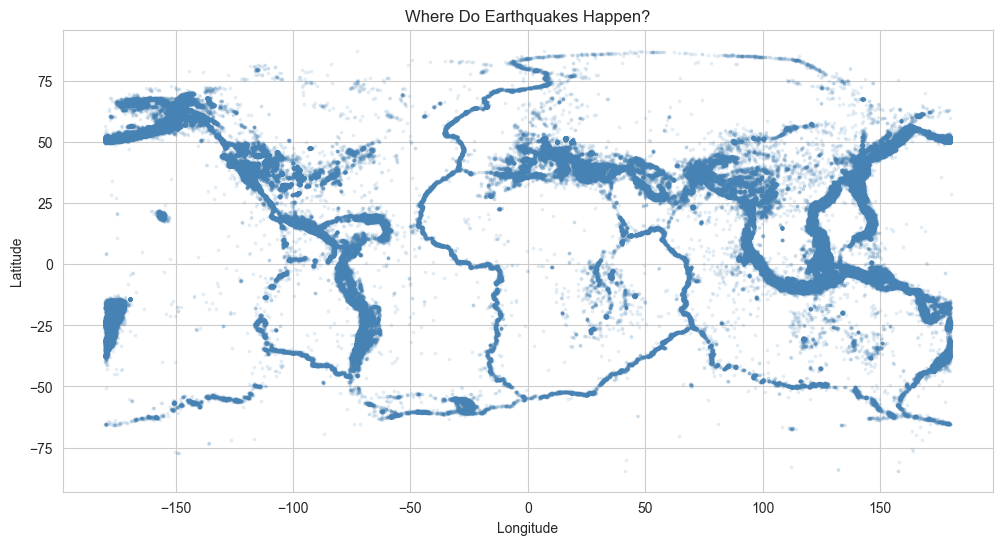

In [35]:
plt.figure(figsize=(12, 6))
plt.scatter(df['longitude'], df['latitude'],
            alpha=0.1, s=3, color='steelblue')

plt.title("Where Do Earthquakes Happen?")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# most earthquakes happen along tectonic plate boundaries
# you can see the Ring of Fire pattern along the Pacific

Pairplot - Comparing Multiple Features at Once
A pairplot shows scatter plots for every combination of selected columns.
The diagonal shows the distribution of each column.
We use a small sample (10%) so it doesn't take too long to run.


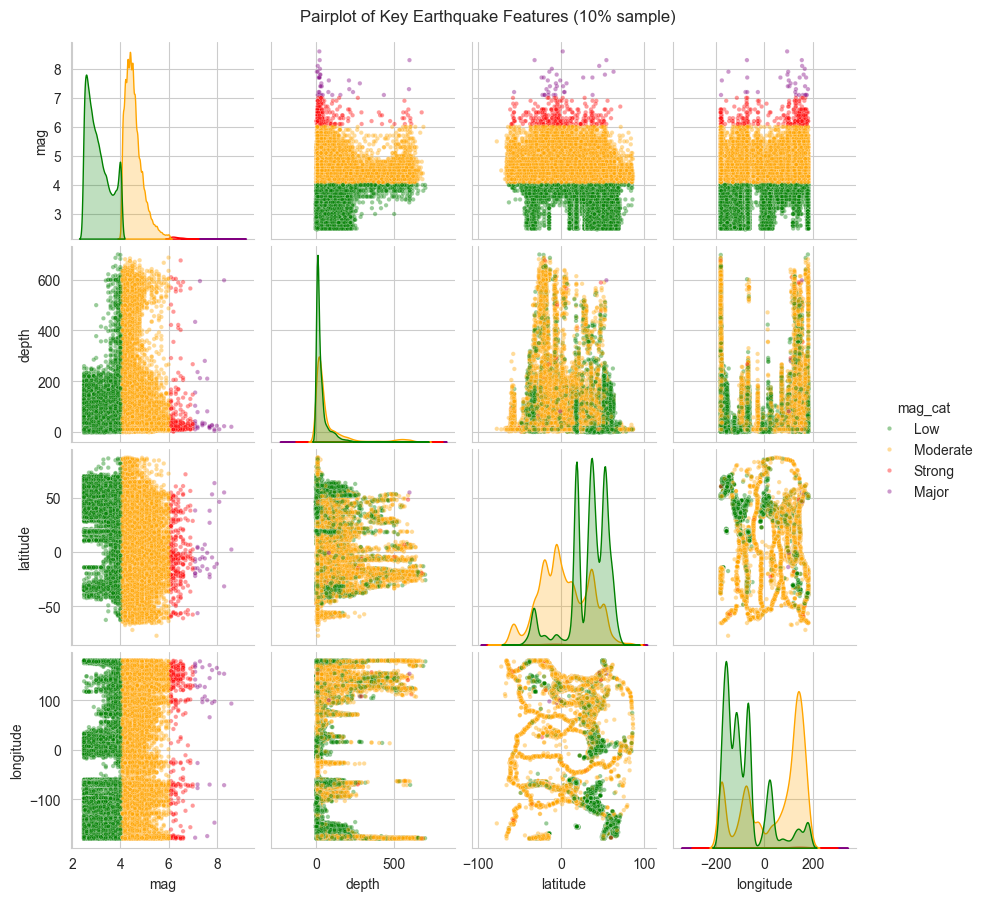

In [36]:
# taking 10% sample for performance - full data makes this very slow
sample_pair = df[['mag','depth','latitude','longitude','mag_cat']].sample(frac=0.10, random_state=1)

sns.pairplot(sample_pair, hue='mag_cat',
             palette={'Low':'green','Moderate':'orange',
                      'Strong':'red','Major':'purple'},
             diag_kind='kde',
             plot_kws={'alpha':0.4, 's':10},
             height=2.2)

plt.suptitle("Pairplot of Key Earthquake Features (10% sample)", y=1.02)
plt.show()


Linear Regression - Predicting Earthquake Magnitude
Now we try to build a simple machine learning model using Linear Regression.
The idea is - can we predict the magnitude of an earthquake using features like depth, year, month, and location?
This falls under supervised learning because we already know the correct magnitude values.

In [40]:
# importing what we need for machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("libraries imported")

libraries imported


Selecting Features and Target
We pick the columns we think might help predict magnitude (these are our features/X).
The column we want to predict is magnitude (this is our target/y).

In [41]:
# choosing features that we think might affect magnitude
features = ['depth', 'latitude', 'longitude', 'year', 'month']

# dropping rows where any of these columns have missing values
df_model = df[features + ['mag']].dropna()

X = df_model[features]   # input features
y = df_model['mag']      # what we want to predict

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (691176, 5)
y shape: (691176,)


Train-Test Split

We split the data into two parts - 80% for training the model and 20% for testing it.
The model learns from the training set and we check how good it is on the test set.
random_state=42 just makes sure we get the same split every time we run it.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("training samples:", len(X_train))
print("testing samples :", len(X_test))

training samples: 552940
testing samples : 138236


Training the Model
We create a Linear Regression model and fit it on the training data.
Fitting means the model finds the best line/equation that maps our features to the magnitude.

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

print("model trained!")

# seeing what coefficients the model came up with for each feature
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print()
print(coef_df.to_string(index=False))
print()
print("Intercept:", round(model.intercept_, 4))
# a positive coefficient means that feature pushes magnitude higher
# a negative one means it brings it down

model trained!

  Feature  Coefficient
    depth     0.000738
 latitude    -0.011215
longitude     0.003006
     year     0.006697
    month     0.001360

Intercept: -9.4496


Evaluating the Model
We use two metrics to check how well the model performed:
MSE (Mean Squared Error) - average of squared differences between predicted and actual values. lower is better.
R² Score - tells us how much of the variation in magnitude our model explains. closer to 1 is better.

In [44]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 30)
print(f"Mean Squared Error : {mse:.4f}")
print(f"R² Score           : {r2:.4f}")
print()
# linear regression on earthquake data usually gives a low R2
# this makes sense because earthquakes are not perfectly predictable from simple features
# but the exercise shows us how to set up and evaluate a regression model

Model Evaluation Results
------------------------------
Mean Squared Error : 0.4206
R² Score           : 0.4410



Predicted vs Actual Plot
This scatter plot compares what the model predicted vs what the actual magnitude was.
If the model was perfect all dots would fall on the red diagonal line.
How spread out they are tells us how accurate the predictions are.

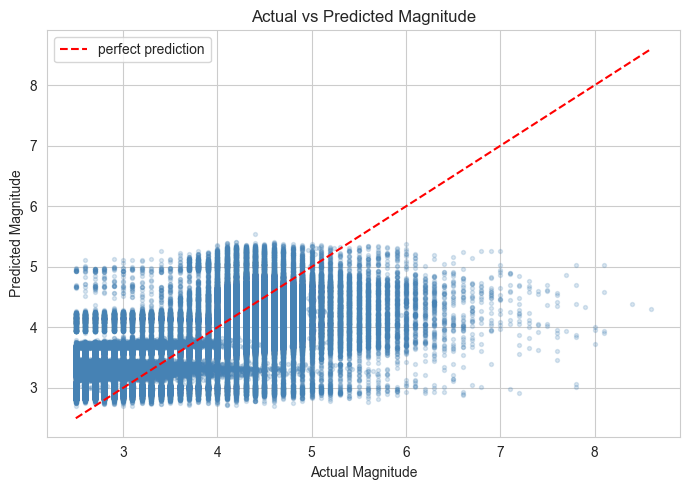

In [45]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')

# drawing the ideal line where predicted = actual
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, linestyle='--', label='perfect prediction')

plt.title("Actual vs Predicted Magnitude")
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.legend()
plt.tight_layout()
plt.show()

# the spread shows the model isnt super accurate which is expected
# earthquake magnitude depends on many geological factors we dont have in this dataset

Residual Plot
Residuals are the difference between actual and predicted values.
A good model should have residuals spread randomly around zero with no pattern.
If we see a clear pattern it means the model is missing something.

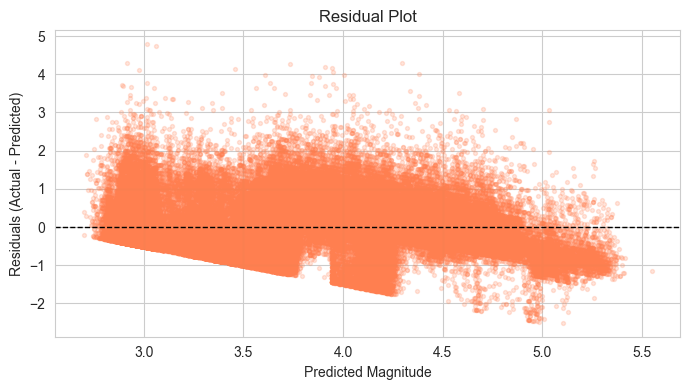

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.2, s=8, color='coral')
plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Magnitude")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()

# residuals are spread around 0 which means there is no major systematic error
# the model is at least unbiased even if it isnt very precise

Final Insights

In [47]:
print("Summary of Key Findings")
print("-" * 45)
print(f"Total earthquakes analyzed : {len(df):,}")
print(f"Time period                : 2000 to 2026")
print(f"Average magnitude          : {df['mag'].mean():.2f}")
print(f"Maximum magnitude          : {df['mag'].max():.1f}")
print(f"Average depth              : {df['depth'].mean():.1f} km")
print()
print("Category breakdown:")
print(df['mag_cat'].value_counts().to_string())
print()
print("Key Observations:")
print("- Most earthquakes are low magnitude and rarely cause damage")
print("- Shallow earthquakes are more common and more dangerous")
print("- No seasonal pattern found - quakes happen throughout the year")
print("- Earthquake locations clearly follow tectonic plate boundaries")
print("- No strong correlation between depth and magnitude")


Summary of Key Findings
---------------------------------------------
Total earthquakes analyzed : 691,176
Time period                : 2000 to 2026
Average magnitude          : 3.80
Maximum magnitude          : 9.1
Average depth              : 56.1 km

Category breakdown:
mag_cat
Low         354104
Moderate    334040
Strong        2717
Major          315

Key Observations:
- Most earthquakes are low magnitude and rarely cause damage
- Shallow earthquakes are more common and more dangerous
- No seasonal pattern found - quakes happen throughout the year
- Earthquake locations clearly follow tectonic plate boundaries
- No strong correlation between depth and magnitude
